# Análisis VAR: Índice Niño 3.4, Aportes Hídricos y Precio de Bolsa de Energía en Colombia

## Evaluación econométrica para el diseño de un derivado climático de cobertura

---

**Objetivo general del proyecto**

Este notebook desarrolla un análisis econométrico completo mediante un modelo de **Vectores Autorregresivos (VAR)** para estudiar la relación dinámica entre tres variables clave del mercado eléctrico colombiano:

1. **Índice Niño 3.4 (SST)** — indicador de anomalías de temperatura superficial del mar en la región Niño 3.4, ampliamente usado para monitorear el fenómeno El Niño–Oscilación del Sur (ENSO).
2. **Aportes hídricos (m³/s)** — caudal de agua que ingresa a los embalses del Sistema Interconectado Nacional (SIN), determinante central de la oferta de generación hidroeléctrica en Colombia.
3. **Precio de bolsa de energía** — precio spot al que se transa la energía eléctrica en el mercado mayorista colombiano.

La hipótesis subyacente, motivada por la literatura sobre economía de la energía y clima, es que las fases cálidas del ENSO (El Niño) reducen la disponibilidad hídrica en Colombia, lo cual restringe la generación hidroeléctrica (que domina la matriz energética) y presiona al alza el precio de bolsa. Si esta cadena de transmisión se confirma estadísticamente, existe una base cuantitativa para diseñar un **derivado climático** (por ejemplo, un contrato indexado al Índice Niño 3.4) que permita a los agentes del mercado cubrir el riesgo de precio asociado a la variabilidad climática.

**Estructura del notebook**

| Sección | Contenido |
|---|---|
| 1 | Importación de librerías |
| 2 | Carga de datos |
| 3 | Visualización exploratoria |
| 4 | Evaluación de estacionariedad y pertinencia del VAR |
| 5 | Selección del número de rezagos |
| 6 | Estimación del modelo VAR |
| 7 | Diagnósticos del modelo |
| 8 | Causalidad de Granger |
| 9 | Funciones impulso-respuesta (IRF) |
| 10 | Descomposición de la varianza (FEVD) |
| 11 | Pronósticos |
| 12 | Conclusiones |

> **Nota sobre los datos:** este notebook espera un archivo CSV llamado `datos_mercado_electrico.csv` ubicado en la misma carpeta, con las columnas `date, indice, aportes, precio` y frecuencia mensual. Si el archivo tiene otro nombre, ajuste la variable `RUTA_DATOS` en la Sección 2.


## 1. Importación de librerías

Se importan únicamente las librerías que se utilizarán a lo largo del notebook:

- **pandas / numpy**: manejo de datos y cálculo numérico.
- **matplotlib**: visualización.
- **scipy.stats**: pruebas estadísticas auxiliares (Jarque-Bera, entre otras).
- **statsmodels**: pruebas de raíz unitaria (ADF, KPSS), estimación del VAR, diagnósticos, Granger, IRF y FEVD.

Se fija una semilla y un estilo gráfico consistente para asegurar reproducibilidad y presentación profesional.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.var_model import VARResults
from statsmodels.stats.stattools import jarque_bera

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
})

np.random.seed(42)
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga de datos

**Qué se hace:** se lee el archivo CSV consolidado, se convierte la columna `date` a formato `datetime` y se establece como índice temporal con frecuencia mensual (`MS`, inicio de mes). No se realiza limpieza adicional porque, según el enunciado del proyecto, esa etapa ya fue completada previamente.

**Por qué se hace así:** `statsmodels` requiere que el índice de un objeto `DataFrame` usado en un VAR tenga una frecuencia temporal explícita y regular; de lo contrario, algunas rutinas (pronóstico, IRF) pueden fallar silenciosamente o generar advertencias. Fijar la frecuencia con `asfreq("MS")` garantiza que el modelo interprete correctamente el espaciamiento temporal entre observaciones.


In [36]:
RUTA_DATOS = "data\RONI_APORTES_PRICE_monthly_2000-2024.csv"
df = pd.read_csv(RUTA_DATOS)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
df = df.asfreq("MS")

# Renombrar a nombres descriptivos manteniendo consistencia con el resto del notebook
df = df.rename(columns={"RONI": "RONI", "APORTES": "APORTES", "ENERGY_PRICE": "ENERGY_PRICE"})

print(f"Rango temporal: {df.index.min().date()} a {df.index.max().date()}")
print(f"Número de observaciones: {len(df)}")
df.head()


Rango temporal: 2000-01-01 a 2024-12-01
Número de observaciones: 300


,RONI,ENERGY_PRICE,APORTES
date,,,
2000-01-01,-1.79,36.778780,884.252935
2000-02-01,-1.53,40.261477,981.598379
2000-03-01,-1.26,37.637297,1088.701935
2000-04-01,-0.80,44.298057,998.995000
2000-05-01,-0.80,37.291122,1723.730000


In [37]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
RONI,300.0,-0.010600,0.824009,-1.790000,-0.587500,-0.085000,0.480000,2.570000
ENERGY_PRICE,300.0,177.633606,196.092882,35.054972,70.606008,107.220757,188.422075,1529.134288
APORTES,300.0,1832.579874,747.864558,487.244643,1315.568000,1764.715887,2238.881382,5128.196203


## 3. Visualización exploratoria

**Por qué se hace:** antes de estimar cualquier modelo econométrico es indispensable entender el comportamiento univariado y conjunto de las series: tendencias, niveles, estacionalidad, atipicidades y correlaciones contemporáneas. Esta exploración informa decisiones posteriores (diferenciación, número de rezagos, interpretación de resultados) y permite detectar problemas de calidad de datos antes de que contaminen el modelo.

### 3.1 Series temporales individuales


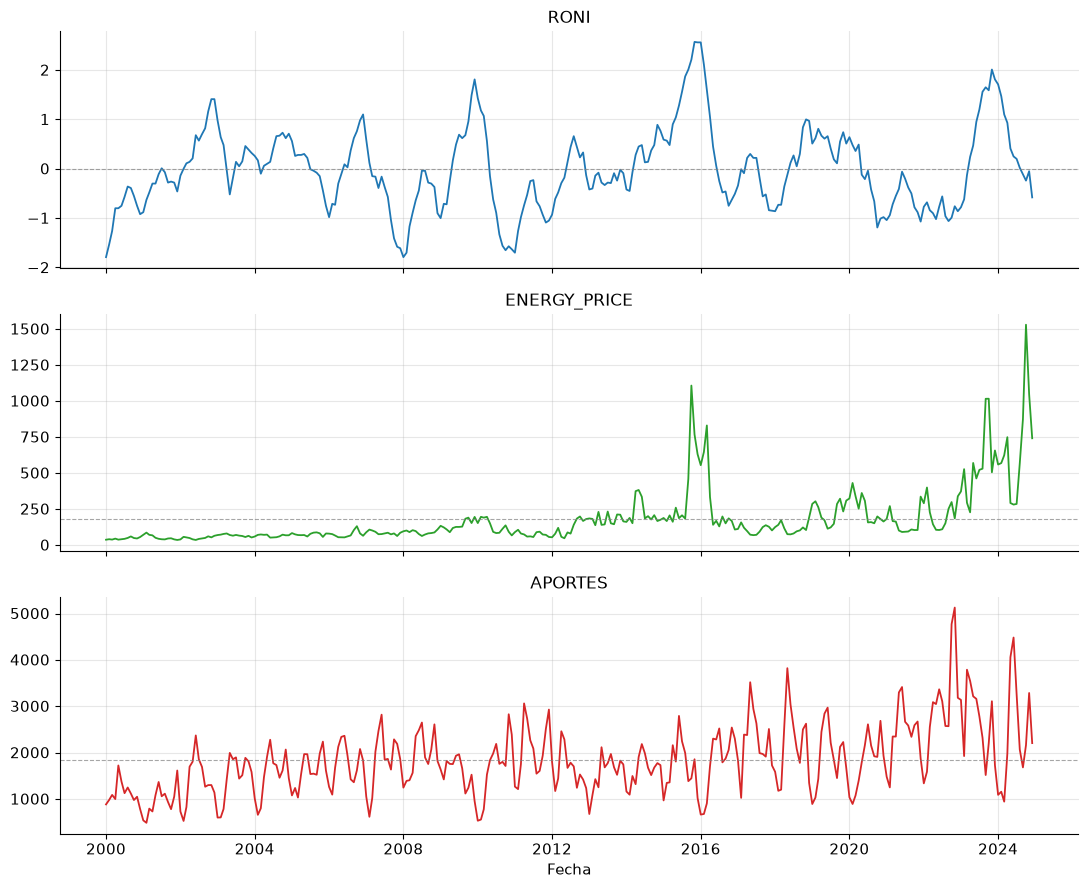

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
colores = ["#1f77b4", "#2ca02c", "#d62728"]
for ax, col, color in zip(axes, df.columns, colores):
    ax.plot(df.index, df[col], color=color, linewidth=1.3)
    ax.set_title(col)
    ax.axhline(df[col].mean(), color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()


**Interpretación:** observe en cada panel si existe una tendencia sostenida (nivel creciente/decreciente en el tiempo), quiebres o cambios de nivel (por ejemplo, coincidiendo con eventos El Niño/La Niña conocidos), estacionalidad visible (patrones que se repiten cada 12 meses, típicos en aportes hídricos por el régimen de lluvias) y valores atípicos (picos abruptos en el precio de bolsa, usualmente asociados a racionamientos o restricciones de oferta).

### 3.2 Series conjuntas con escala normalizada

Para comparar las tres series en una misma figura pese a tener unidades distintas (°C, m³/s, $/kWh), se normalizan mediante z-score. Esto NO altera el modelo posterior — es únicamente una herramienta visual.


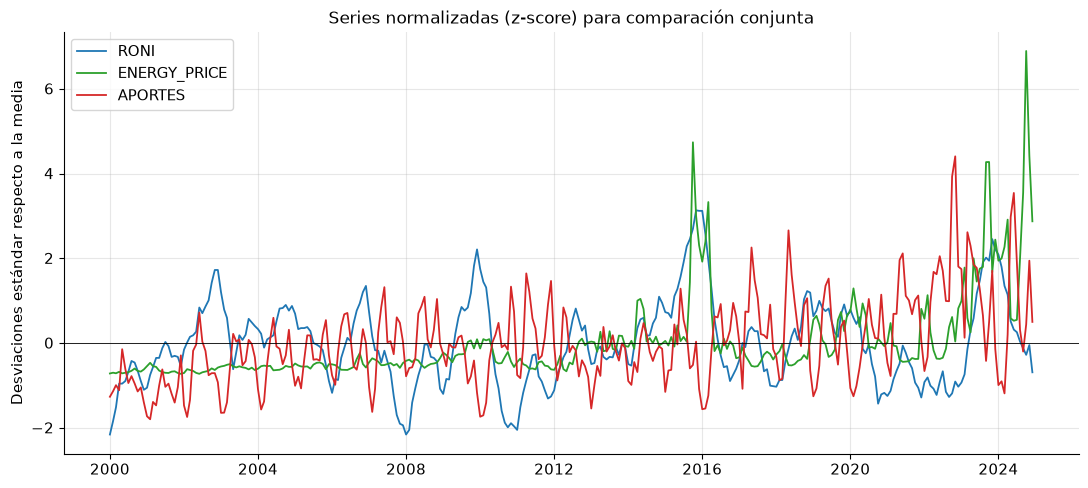

In [39]:
df_norm = (df - df.mean()) / df.std()

fig, ax = plt.subplots(figsize=(11, 5))
for col, color in zip(df.columns, colores):
    ax.plot(df_norm.index, df_norm[col], label=col, color=color, linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Series normalizadas (z-score) para comparación conjunta")
ax.set_ylabel("Desviaciones estándar respecto a la media")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación:** esta figura facilita identificar co-movimientos: por ejemplo, si los picos del Índice Niño 3.4 preceden a caídas en los aportes hídricos y estas, a su vez, preceden a subidas en el precio de bolsa, se tiene evidencia visual preliminar de la cadena de transmisión hipotetizada (El Niño → menor hidrología → mayor precio).

### 3.3 Distribuciones: histogramas, boxplots y densidades


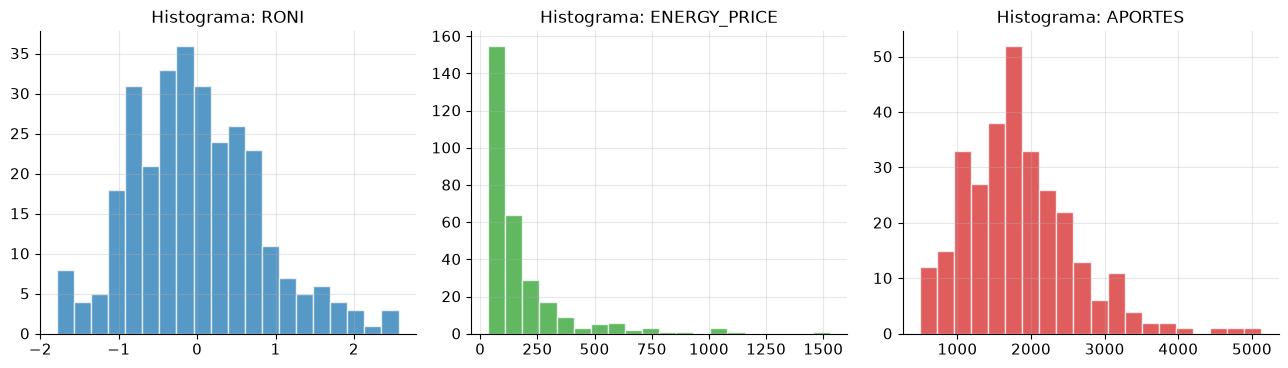

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, color in zip(axes, df.columns, colores):
    ax.hist(df[col].dropna(), bins=20, color=color, alpha=0.75, edgecolor="white")
    ax.set_title(f"Histograma: {col}")
plt.tight_layout()
plt.show()


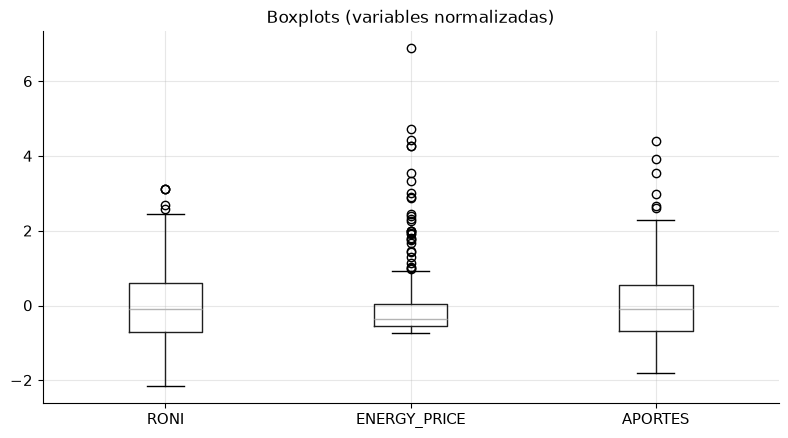

In [41]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df_norm.boxplot(ax=ax)
ax.set_title("Boxplots (variables normalizadas)")
plt.tight_layout()
plt.show()


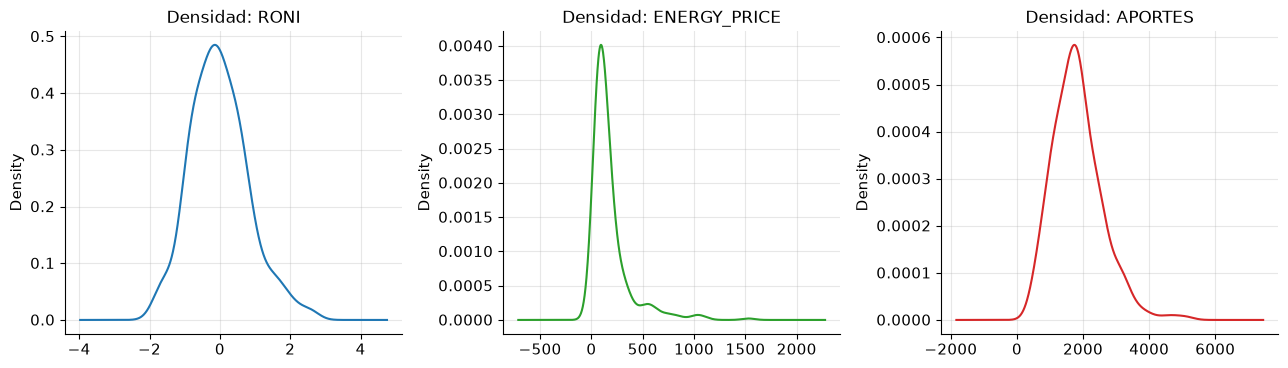

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, color in zip(axes, df.columns, colores):
    df[col].plot(kind="density", ax=ax, color=color, linewidth=1.5)
    ax.set_title(f"Densidad: {col}")
plt.tight_layout()
plt.show()


**Interpretación:** los histogramas y densidades permiten evaluar simetría y presencia de colas pesadas (el precio de bolsa, típicamente, exhibe asimetría positiva por eventos extremos de escasez). Los boxplots identifican valores atípicos (puntos fuera de los bigotes) que conviene tener presentes al interpretar coeficientes del VAR más adelante.

### 3.4 Matriz de dispersión (pairplot)


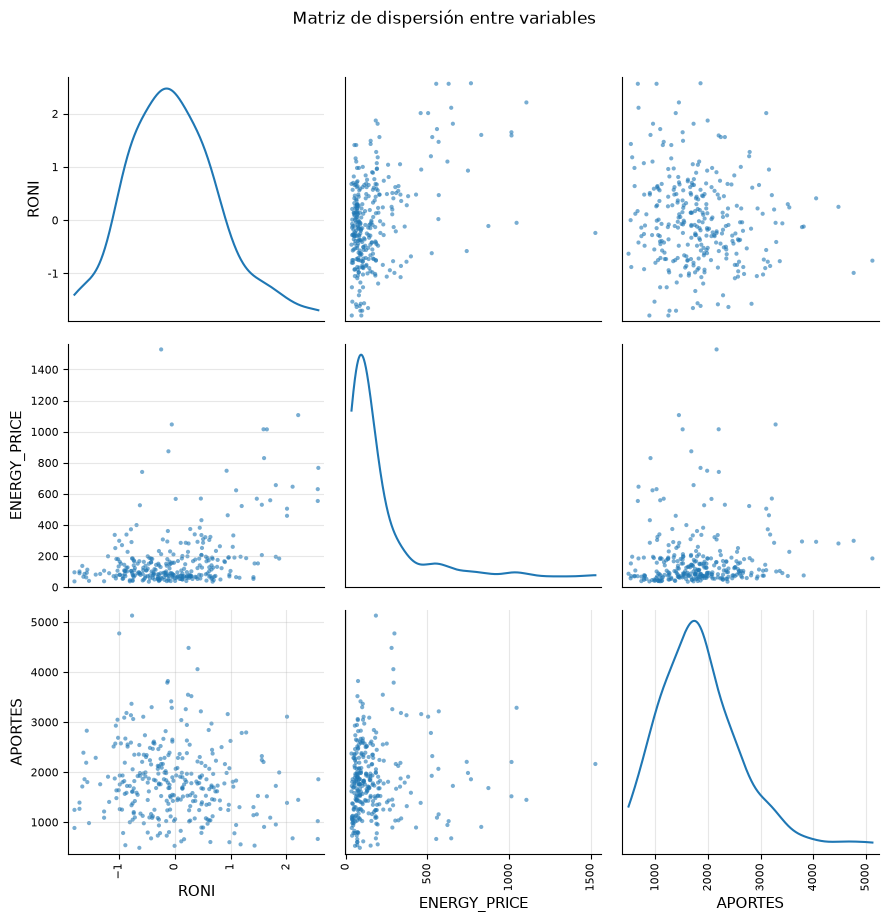

In [43]:
from pandas.plotting import scatter_matrix

axes_matrix = scatter_matrix(df, figsize=(9, 9), diagonal="kde",
                              color="#1f77b4", alpha=0.6, hist_kwds={"bins": 20})
plt.suptitle("Matriz de dispersión entre variables", y=1.02)
plt.tight_layout()
plt.show()


**Interpretación:** los paneles fuera de la diagonal muestran relaciones contemporáneas bivariadas. Una nube de puntos con pendiente negativa clara entre `Aportes_Hidricos` y `Precio_Bolsa` sería consistente con la teoría (menor hidrología → mayor precio); relaciones difusas no descartan causalidad dinámica, ya que el VAR captura relaciones **rezagadas**, no solo contemporáneas.

### 3.5 Matriz y heatmap de correlaciones


In [44]:
corr = df.corr()
print("Matriz de correlaciones (Pearson):")
corr.round(3)


Matriz de correlaciones (Pearson):


,RONI,ENERGY_PRICE,APORTES
RONI,1.000,0.403,-0.139
ENERGY_PRICE,0.403,1.000,0.065
APORTES,-0.139,0.065,1.000


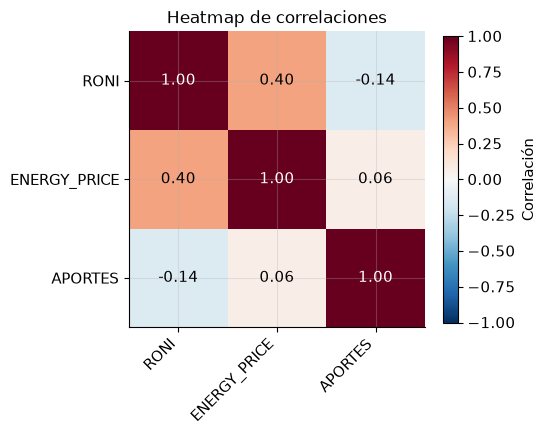

In [45]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación")
ax.set_title("Heatmap de correlaciones")
plt.tight_layout()
plt.show()


**Interpretación:** las correlaciones contemporáneas son un punto de partida, pero **no sustituyen** el análisis dinámico que provee el VAR. Una correlación baja no implica ausencia de relación causal-temporal (el efecto del clima sobre el precio puede materializarse con rezago de varios meses), mientras que una correlación alta no implica causalidad.

**Conclusión de la sección:** la exploración visual sugiere posibles cambios de nivel y volatilidad diferenciada entre las series, así como co-movimientos consistentes con la hipótesis de transmisión ENSO → hidrología → precio. Estos hallazgos motivan formalmente el análisis de estacionariedad y la estimación del VAR en las secciones siguientes.


## 4. ¿Es apropiado usar un VAR?

### 4.1 ¿Qué es un modelo VAR?

Un **Vector Autorregresivo (VAR)** de orden *p* modela cada variable de un sistema como una función lineal de sus propios rezagos y de los rezagos de todas las demás variables del sistema. Para un vector de variables $Y_t = (y_{1t}, y_{2t}, y_{3t})'$, un VAR(p) se escribe como:

$$Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \dots + A_p Y_{t-p} + \varepsilon_t$$

donde $c$ es un vector de constantes, $A_i$ son matrices de coeficientes y $\varepsilon_t$ es un vector de errores ruido blanco.

### 4.2 ¿Cuándo debe utilizarse?

El VAR es apropiado cuando:

- Existen **múltiples variables interrelacionadas** sin una dirección de causalidad impuesta a priori por la teoría (a diferencia de un modelo estructural uniecuacional).
- Interesa capturar **dinámicas de retroalimentación** (feedback) entre variables — p. ej., el precio puede a su vez influir en decisiones de despacho que afecten los aportes reportados.
- Se busca analizar **respuestas a shocks** (IRF) y **descomposición de varianza** (FEVD), herramientas naturales del marco VAR.

### 4.3 Supuestos clave

1. **Estacionariedad** de las series (o de las series transformadas) que entran al modelo.
2. **Ausencia de autocorrelación** en los residuos (si existiera, indicaría rezagos mal especificados).
3. **Errores con varianza finita** y, idealmente, aproximadamente normales para inferencia válida en muestras pequeñas.
4. **Estabilidad** del sistema: las raíces características del proceso deben ubicarse dentro del círculo unitario.

### 4.4 ¿Por qué es importante verificar estos supuestos?

Estimar un VAR sobre series no estacionarias con tendencia estocástica puede producir **regresiones espurias**: relaciones estadísticamente "significativas" que no reflejan ninguna relación económica real, simplemente porque ambas series tienden a moverse en el tiempo. Verificar estacionariedad es, por tanto, el primer paso obligatorio antes de estimar cualquier VAR en niveles.

---

### 4.5 Pruebas de estacionariedad: ADF y KPSS

**Prueba ADF (Augmented Dickey-Fuller):**
- $H_0$: la serie tiene una raíz unitaria (no es estacionaria).
- $H_1$: la serie es estacionaria.
- Se rechaza $H_0$ (concluyendo estacionariedad) cuando el p-value es menor al nivel de significancia (usualmente 0.05).

**Prueba KPSS (Kwiatkowski-Phillips-Schmidt-Shin):**
- $H_0$: la serie es estacionaria (hipótesis invertida respecto a ADF).
- $H_1$: la serie tiene raíz unitaria.
- Se rechaza $H_0$ (concluyendo no estacionariedad) cuando el p-value es menor al nivel de significancia.

**Por qué usar ambas:** ADF y KPSS tienen hipótesis nulas opuestas. Usarlas conjuntamente permite una conclusión más robusta:

| ADF | KPSS | Conclusión |
|---|---|---|
| Rechaza H0 (estacionaria) | No rechaza H0 (estacionaria) | Estacionaria — evidencia fuerte |
| No rechaza H0 (no estac.) | Rechaza H0 (no estac.) | No estacionaria — evidencia fuerte |
| Resultados discrepantes | | Evidencia mixta — requiere juicio adicional (posible estacionariedad en tendencia, o baja potencia de alguna prueba) |

**Limitaciones:** ambas pruebas tienen baja potencia estadística en muestras pequeñas y son sensibles a la especificación de rezagos/tendencia elegida.


In [46]:
def prueba_adf(serie, nombre):
    resultado = adfuller(serie.dropna(), autolag="AIC")
    return {
        "Variable": nombre,
        "ADF_estadistico": round(resultado[0], 4),
        "ADF_p_value": round(resultado[1], 4),
        "ADF_conclusion": "Estacionaria" if resultado[1] < 0.05 else "No estacionaria",
    }

def prueba_kpss(serie, nombre):
    resultado = kpss(serie.dropna(), regression="c", nlags="auto")
    return {
        "Variable": nombre,
        "KPSS_estadistico": round(resultado[0], 4),
        "KPSS_p_value": round(resultado[1], 4),
        "KPSS_conclusion": "Estacionaria" if resultado[1] > 0.05 else "No estacionaria",
    }

filas = []
for col in df.columns:
    adf_res = prueba_adf(df[col], col)
    kpss_res = prueba_kpss(df[col], col)
    filas.append({**adf_res, **{k: v for k, v in kpss_res.items() if k != "Variable"}})

tabla_estacionariedad = pd.DataFrame(filas).set_index("Variable")
tabla_estacionariedad


,ADF_estadistico,ADF_p_value,ADF_conclusion,KPSS_estadistico,KPSS_p_value,KPSS_conclusion
Variable,,,,,,
RONI,-4.2158,0.0006,Estacionaria,0.1036,0.10,Estacionaria
ENERGY_PRICE,-0.4292,0.9051,No estacionaria,1.4528,0.01,No estacionaria
APORTES,-2.8254,0.0547,No estacionaria,1.8206,0.01,No estacionaria


**Interpretación de la tabla:** revise, para cada variable, si ADF y KPSS coinciden en su diagnóstico. Si alguna serie resulta no estacionaria (caso habitual en `Aportes_Hidricos` y `Precio_Bolsa`, que suelen tener niveles cambiantes), se aplicará una diferenciación de primer orden.

### 4.6 Diferenciación (si aplica)

**Por qué diferenciar:** la diferenciación de primer orden, $\Delta y_t = y_t - y_{t-1}$, elimina la raíz unitaria de un proceso integrado de orden 1, I(1), convirtiéndolo en estacionario, I(0). Esto es necesario porque el VAR estándar en niveles asume estacionariedad; de lo contrario, los estadísticos t y F pierden su distribución asintótica estándar.


In [47]:
df_dif = df.diff().dropna()

filas_dif = []
for col in df_dif.columns:
    adf_res = prueba_adf(df_dif[col], col)
    kpss_res = prueba_kpss(df_dif[col], col)
    filas_dif.append({**adf_res, **{k: v for k, v in kpss_res.items() if k != "Variable"}})

tabla_estacionariedad_dif = pd.DataFrame(filas_dif).set_index("Variable")
tabla_estacionariedad_dif


,ADF_estadistico,ADF_p_value,ADF_conclusion,KPSS_estadistico,KPSS_p_value,KPSS_conclusion
Variable,,,,,,
RONI,-4.7904,0.0001,Estacionaria,0.0488,0.1,Estacionaria
ENERGY_PRICE,-5.3574,0.0000,Estacionaria,0.1639,0.1,Estacionaria
APORTES,-5.7078,0.0000,Estacionaria,0.1838,0.1,Estacionaria


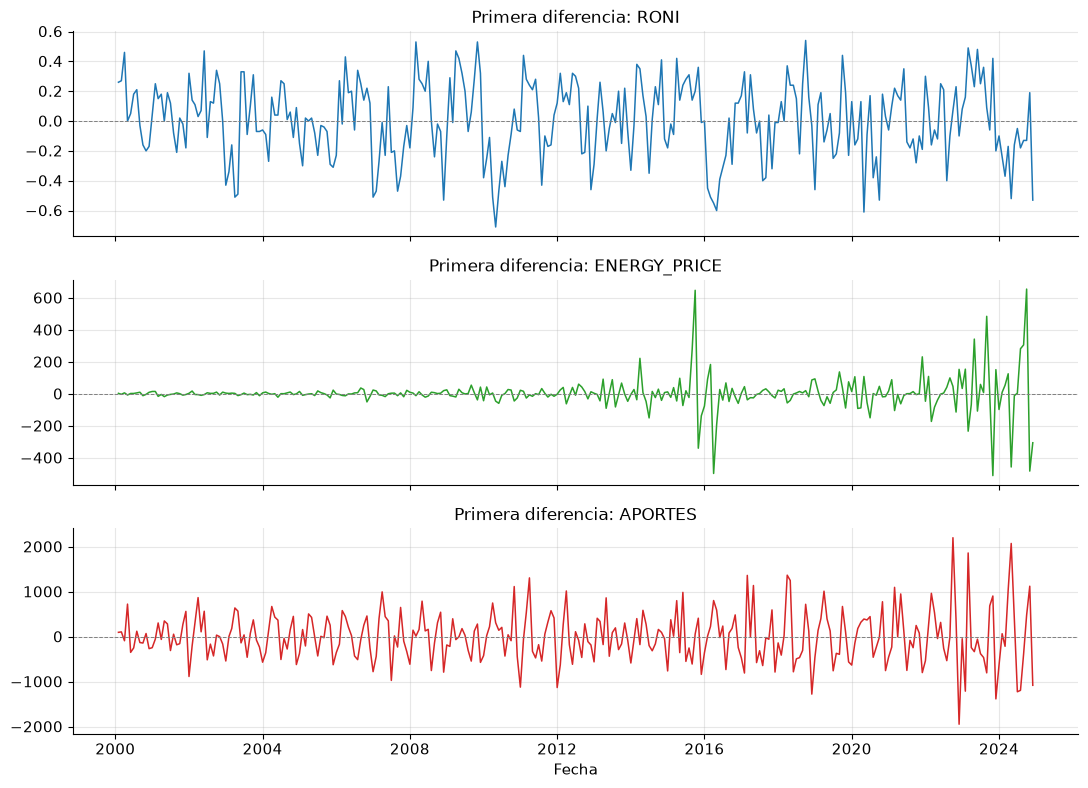

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, col, color in zip(axes, df_dif.columns, colores):
    ax.plot(df_dif.index, df_dif[col], color=color, linewidth=1.1)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title(f"Primera diferencia: {col}")
axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()


**Interpretación:** tras diferenciar, las series deberían oscilar alrededor de cero sin tendencia visible, y la tabla ADF/KPSS re-verificada debería indicar estacionariedad para todas las variables. 

> **Decisión metodológica:** el bloque siguiente define de forma programática si el VAR se estimará en niveles o en diferencias, según el resultado formal de las pruebas. Esto asegura que la decisión no dependa de un juicio manual sino del resultado estadístico obtenido con **los datos del usuario**.


In [49]:
# Regla de decisión: si TODAS las series son estacionarias en niveles según ambas pruebas,
# se usa el VAR en niveles; de lo contrario, se usa el VAR en primeras diferencias.
niveles_ok = all(
    (tabla_estacionariedad.loc[c, "ADF_conclusion"] == "Estacionaria") and
    (tabla_estacionariedad.loc[c, "KPSS_conclusion"] == "Estacionaria")
    for c in df.columns
)

if niveles_ok:
    datos_var = df.copy()
    transformacion = "niveles"
else:
    datos_var = df_dif.copy()
    transformacion = "primeras diferencias"

print(f"Conjunto de datos que entrará al VAR: variables en {transformacion.upper()}")
datos_var.head()


Conjunto de datos que entrará al VAR: variables en PRIMERAS DIFERENCIAS


,RONI,ENERGY_PRICE,APORTES
date,,,
2000-02-01,0.26,3.482697,97.345444
2000-03-01,0.27,-2.624179,107.103556
2000-04-01,0.46,6.660760,-89.706935
2000-05-01,0.00,-7.006936,724.735000
2000-06-01,0.05,2.702081,-347.975000


**Conclusión de la sección:** el conjunto `datos_var` construido arriba —en niveles o en diferencias, según lo que determinaron ADF y KPSS— es el que se utilizará en todas las secciones siguientes (selección de rezagos, estimación, diagnósticos, Granger, IRF, FEVD y pronósticos). Esto garantiza que el modelo VAR se apoye sobre series estacionarias, condición necesaria para una inferencia estadística válida.


## 5. Elección del número de rezagos

**Por qué es importante:** el número de rezagos $p$ determina cuánta "memoria" tiene el sistema. Es una de las decisiones más críticas en la especificación de un VAR.

- **Muy pocos rezagos:** el modelo puede omitir dinámicas relevantes, dejando autocorrelación en los residuos (mala especificación) y sesgando las IRF y la causalidad de Granger.
- **Demasiados rezagos:** se consume rápidamente el número de grados de libertad (cada rezago adicional añade $k^2$ parámetros, con $k$ el número de variables), aumentando el riesgo de sobreajuste y de coeficientes poco precisos (varianza alta), especialmente relevante aquí porque se trabaja con series mensuales de longitud moderada.

**Criterios de información:**

- **AIC (Akaike):** penaliza menos la complejidad; tiende a elegir modelos con más rezagos.
- **BIC (Schwarz):** penaliza más fuertemente el número de parámetros; tiende a elegir modelos más parsimoniosos, consistente asintóticamente.
- **HQIC (Hannan-Quinn):** penalización intermedia entre AIC y BIC.
- **FPE (Final Prediction Error):** estima el error de predicción fuera de muestra; en la práctica se comporta de forma similar al AIC.

**Criterio a utilizar:** dado el tamaño de muestra típicamente moderado de series mensuales de mercado eléctrico, se prioriza **BIC** por su mayor parsimonia y menor riesgo de sobreajuste, contrastando el resultado con AIC y HQIC para verificar consistencia.


In [50]:
modelo_seleccion = VAR(datos_var)
rezago_maximo = min(12, int(len(datos_var) / 4))  # regla práctica: no más de N/4 rezagos

resultado_orden = modelo_seleccion.select_order(maxlags=rezago_maximo)
print(resultado_orden.summary())


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        19.21       19.25   2.202e+08       19.23
1        18.81       18.97   1.479e+08       18.87
2        18.76       19.02   1.400e+08       18.86
3        18.53      18.91*   1.110e+08       18.68
4        18.53       19.02   1.111e+08       18.72
5        18.51       19.12   1.094e+08       18.76
6        18.48       19.21   1.063e+08       18.77
7        18.51       19.35   1.092e+08       18.85
8        18.50       19.46   1.088e+08       18.89
9        18.40       19.48   9.858e+07       18.83
10       18.25       19.43   8.436e+07       18.72
11      18.14*       19.44  7.573e+07*      18.66*
12       18.17       19.58   7.803e+07       18.74
--------------------------------------------------


In [51]:
criterios = pd.DataFrame({
    "AIC": resultado_orden.aic,
    "BIC": resultado_orden.bic,
    "HQIC": resultado_orden.hqic,
    "FPE": resultado_orden.fpe,
}, index=[f"lag_{i}" for i in range(len(resultado_orden.aic))]) if False else None

# select_order ya imprime la tabla resumen; extraemos el rezago óptimo por cada criterio
ordenes = {
    "AIC": resultado_orden.selected_orders["aic"],
    "BIC": resultado_orden.selected_orders["bic"],
    "HQIC": resultado_orden.selected_orders["hqic"],
    "FPE": resultado_orden.selected_orders["fpe"],
}
tabla_ordenes = pd.DataFrame([ordenes], index=["Rezago óptimo sugerido"])
tabla_ordenes


,AIC,BIC,HQIC,FPE
Rezago óptimo sugerido,11,3,11,11


In [52]:
REZAGO_OPTIMO = resultado_orden.selected_orders["bic"]
REZAGO_OPTIMO = max(REZAGO_OPTIMO, 1)  # asegurar al menos 1 rezago
print(f"Número de rezagos seleccionado para el VAR (criterio BIC): p = {REZAGO_OPTIMO}")


Número de rezagos seleccionado para el VAR (criterio BIC): p = 3


**Interpretación y justificación:** se reporta el rezago óptimo sugerido por cada criterio. Cuando los criterios difieren (situación común, ya que AIC/FPE suelen sugerir más rezagos que BIC/HQIC), se opta por **BIC** dado el tamaño de muestra disponible, priorizando parsimonia sobre ajuste marginal. Si el modelo resultante muestra problemas de autocorrelación en los residuos en la Sección 7, se reconsiderará un rezago mayor (p. ej., el sugerido por AIC).

**Conclusión de la sección:** el VAR se estimará con $p = $ `REZAGO_OPTIMO` rezagos, valor que se utilizará consistentemente en el resto del notebook.


## 6. Estimación del modelo VAR

Con el número de rezagos determinado en la sección anterior, se procede a estimar el modelo VAR(p) por mínimos cuadrados ordinarios ecuación por ecuación (equivalente a máxima verosimilitud bajo normalidad de los residuos), tal como lo implementa `statsmodels`.


In [53]:
# REZAGO_OPTIMO = 11 # Cambiar a preferencia por diferentes resultados

modelo_var = VAR(datos_var)
resultado_var = modelo_var.fit(REZAGO_OPTIMO)
print(resultado_var.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     13:29:52
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    18.8387
Nobs:                     296.000    HQIC:                   18.6145
Log likelihood:          -3962.79    FPE:                1.04508e+08
AIC:                      18.4647    Det(Omega_mle):     9.45936e+07
--------------------------------------------------------------------
Results for equation RONI
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.002953         0.013170           -0.224           0.823
L1.RONI                 0.415983         0.059457            6.996           0.000
L1.ENERGY_PRICE         0.000483         0.000141    

### 6.1 Cómo leer el `summary()`

El resultado presenta **una ecuación por cada variable del sistema** (aquí, tres ecuaciones). Para cada ecuación:

- La columna `coefficient` reporta el efecto estimado de cada regresor (constante y rezagos de las tres variables) sobre la variable dependiente de esa ecuación.
- `std. error` es el error estándar del coeficiente; `t-stat` y `prob` permiten evaluar significancia individual (convencionalmente, `prob < 0.05` indica significancia al 5%).
- **Signo del coeficiente:** un coeficiente positivo indica que un aumento en el regresor rezagado se asocia, ceteris paribus, con un aumento en la variable dependiente actual; un coeficiente negativo indica el efecto contrario.
- **Magnitud:** al estar las variables potencialmente en diferentes unidades (y posiblemente diferenciadas), la magnitud debe interpretarse con cautela — es más informativa la comparación de magnitudes entre rezagos de una misma variable que la comparación cruzada entre variables de distinta escala.
- **Rezago:** el subíndice `L1`, `L2`, ... indica cuántos períodos atrás se ubica el regresor. Coeficientes significativos en rezagos altos sugieren efectos que tardan varios meses en manifestarse — relevante para el diseño de un derivado climático, que necesita anticipar el horizonte en el que el riesgo climático se traslada a precio.

### 6.2 Ecuaciones estimadas del VAR

A continuación se construyen explícitamente las ecuaciones matemáticas del modelo estimado, sustituyendo los coeficientes obtenidos.


In [54]:
def construir_ecuacion(resultado, variable_dependiente):
    params = resultado.params[variable_dependiente]
    terminos = [f"{params['const']:.4f}"]
    for nombre_param, valor in params.items():
        if nombre_param == "const":
            continue
        signo = "+" if valor >= 0 else "-"
        terminos.append(f"{signo} {abs(valor):.4f}\u00b7{nombre_param}")
    ecuacion = f"{variable_dependiente}_t = " + " ".join(terminos)
    return ecuacion

print("Ecuaciones estimadas del modelo VAR:\n")
for var_dep in datos_var.columns:
    print(construir_ecuacion(resultado_var, var_dep))
    print()


Ecuaciones estimadas del modelo VAR:

RONI_t = -0.0030 + 0.4160·L1.RONI + 0.0005·L1.ENERGY_PRICE + 0.0000·L1.APORTES - 0.0031·L2.RONI - 0.0000·L2.ENERGY_PRICE - 0.0000·L2.APORTES + 0.0870·L3.RONI - 0.0000·L3.ENERGY_PRICE - 0.0000·L3.APORTES

ENERGY_PRICE_t = 5.5249 + 62.0799·L1.RONI - 0.2461·L1.ENERGY_PRICE - 0.0540·L1.APORTES + 24.4283·L2.RONI - 0.2799·L2.ENERGY_PRICE - 0.0210·L2.APORTES - 0.3805·L3.RONI - 0.2567·L3.ENERGY_PRICE - 0.0268·L3.APORTES

APORTES_t = 5.1583 - 95.3975·L1.RONI + 1.2992·L1.ENERGY_PRICE + 0.0996·L1.APORTES - 162.7540·L2.RONI - 0.2099·L2.ENERGY_PRICE - 0.1354·L2.APORTES - 100.3498·L3.RONI - 0.6599·L3.ENERGY_PRICE - 0.4153·L3.APORTES



**Interpretación económica de las relaciones más relevantes:** revise, en la salida anterior, los coeficientes asociados a `Indice_Nino34` dentro de la ecuación de `Precio_Bolsa`, y los coeficientes de `Indice_Nino34` dentro de la ecuación de `Aportes_Hidricos`. Un patrón consistente con la hipótesis de transmisión climática sería: coeficiente positivo y significativo de `Indice_Nino34` rezagado sobre `Precio_Bolsa` (fases cálidas de ENSO anticipan mayores precios), y coeficiente negativo y significativo de `Indice_Nino34` rezagado sobre `Aportes_Hidricos` (fases cálidas anticipan menor hidrología). De confirmarse ambos signos, se refuerza el argumento de que el riesgo climático medido por el Índice Niño 3.4 es un candidato razonable como subyacente de un derivado climático para el mercado eléctrico colombiano.

**Conclusión de la sección:** el modelo VAR(p) ha sido estimado y sus ecuaciones documentadas explícitamente. La validez de esta estimación depende de que los residuos satisfagan los supuestos verificados en la siguiente sección.


## 7. Diagnósticos del modelo

**Por qué deben verificarse:** toda la inferencia posterior (Granger, IRF, FEVD, pronósticos) es válida solo si el VAR estimado es **estable** y sus residuos se comportan como ruido blanco aproximadamente normal. Si estos supuestos fallan, los intervalos de confianza y p-values calculados en secciones posteriores pueden ser engañosos.

### 7.1 Estabilidad del VAR

Un VAR(p) es estable si todas las raíces del polinomio característico asociado se ubican **fuera** del círculo unitario (equivalentemente, los módulos inversos —tal como los reporta `statsmodels`— se ubican **dentro** del círculo unitario). Un VAR estable garantiza que los shocks tienen efecto transitorio (las IRF convergen a cero) y que el proceso es covarianza-estacionario.


In [55]:
raices = resultado_var.roots
modulos_inversos = 1 / np.abs(raices)

print("Raíces del VAR (módulo del inverso, deben ser < 1 para estabilidad):")
for r, m in zip(raices, modulos_inversos):
    print(f"  raíz = {r:.4f}   |1/raíz| = {m:.4f}   {'OK (estable)' if m < 1 else 'FUERA — inestable'}")

es_estable = resultado_var.is_stable()
print(f"\n¿El VAR es estable según statsmodels? {es_estable}")


Raíces del VAR (módulo del inverso, deben ser < 1 para estabilidad):
  raíz = -0.7943+2.5078j   |1/raíz| = 0.3801   OK (estable)
  raíz = -0.7943-2.5078j   |1/raíz| = 0.3801   OK (estable)
  raíz = -1.8920-0.0000j   |1/raíz| = 0.5285   OK (estable)
  raíz = 0.5329+1.5973j   |1/raíz| = 0.5939   OK (estable)
  raíz = 0.5329-1.5973j   |1/raíz| = 0.5939   OK (estable)
  raíz = -1.5436-0.0000j   |1/raíz| = 0.6478   OK (estable)
  raíz = 1.5347-0.0000j   |1/raíz| = 0.6516   OK (estable)
  raíz = 0.4555+1.0947j   |1/raíz| = 0.8434   OK (estable)
  raíz = 0.4555-1.0947j   |1/raíz| = 0.8434   OK (estable)

¿El VAR es estable según statsmodels? True


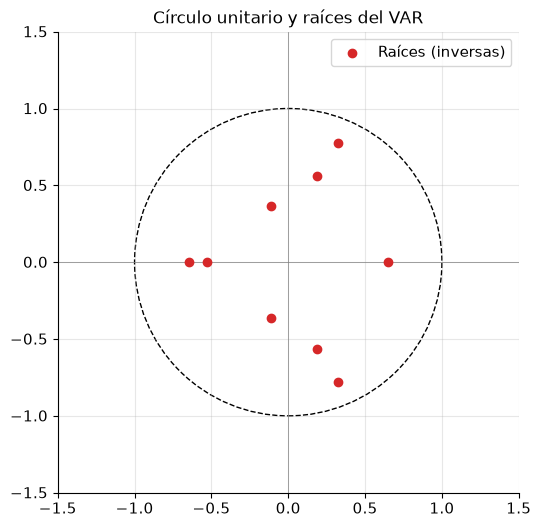

In [56]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
circulo = plt.Circle((0, 0), 1, fill=False, color="black", linestyle="--", linewidth=1)
ax.add_artist(circulo)
inversos = 1 / raices
ax.scatter(inversos.real, inversos.imag, color="#d62728", zorder=5, label="Raíces (inversas)")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")
ax.set_title("Círculo unitario y raíces del VAR")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación:** si todos los puntos rojos caen **dentro** del círculo unitario, el VAR es estable y los resultados de IRF/FEVD/pronósticos son interpretables con confianza. Si algún punto cae fuera o muy cerca del borde, el modelo puede estar mal especificado (posiblemente requiere más diferenciación o un número distinto de rezagos).

### 7.2 Autocorrelación de residuos: prueba de Portmanteau (Whiteness test)

**Qué evalúa:** si, tras controlar por los rezagos incluidos, aún queda autocorrelación serial significativa en los residuos. $H_0$: no hay autocorrelación serial (los residuos son ruido blanco).


In [57]:
prueba_portmanteau = resultado_var.test_whiteness(nlags=REZAGO_OPTIMO+4)
print(prueba_portmanteau.summary())


Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 7 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         64.27          51.00   0.003 36
----------------------------------------


**Interpretación:** un p-value mayor a 0.05 no permite rechazar $H_0$, es decir, no hay evidencia de autocorrelación residual — el número de rezagos elegido parece adecuado. Un p-value pequeño sugeriría revisar el número de rezagos (posiblemente aumentar $p$).

### 7.3 Normalidad de los residuos

**Qué evalúa:** la prueba de Jarque-Bera contrasta $H_0$: los residuos siguen una distribución normal, basándose en el sesgo (asimetría) y la curtosis muestral.


In [58]:
prueba_normalidad = resultado_var.test_normality()
print(prueba_normalidad.summary())


normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         5332.          12.59   0.000  6
----------------------------------------


**Interpretación:** en series económicas y financieras es común rechazar la normalidad estricta (colas más pesadas de lo normal, especialmente en el precio de bolsa por eventos extremos de escasez). Esto no invalida el VAR en sí —los estimadores OLS siguen siendo consistentes— pero sí sugiere tomar con cautela los intervalos de confianza basados en la distribución normal asintótica, particularmente en IRF con muestras pequeñas.

### 7.4 Heterocedasticidad

`statsmodels` no ofrece una prueba de heterocedasticidad multivariada nativa para objetos `VARResults` (a diferencia de ADF/KPSS o Portmanteau). Como alternativa práctica, se aplica la prueba de **Breusch-Pagan** univariada sobre los residuos de cada ecuación del VAR frente a los regresores del sistema, lo que permite un diagnóstico aproximado ecuación por ecuación.


In [59]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

residuos = resultado_var.resid
X_con_const = sm.add_constant(resultado_var.exog if hasattr(resultado_var, "exog") and resultado_var.exog is not None
                               else np.arange(len(residuos)))

filas_bp = []
for col in residuos.columns:
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuos[col], X_con_const)
    filas_bp.append({
        "Ecuación": col,
        "BP_estadistico": round(bp_stat, 4),
        "BP_p_value": round(bp_pvalue, 4),
        "Conclusión": "Heterocedasticidad" if bp_pvalue < 0.05 else "Homocedasticidad (no se rechaza)"
    })

tabla_heterocedasticidad = pd.DataFrame(filas_bp).set_index("Ecuación")
tabla_heterocedasticidad


,BP_estadistico,BP_p_value,Conclusión
Ecuación,,,
RONI,0.6493,0.4204,Homocedasticidad (no se rechaza)
ENERGY_PRICE,15.5530,0.0001,Heterocedasticidad
APORTES,21.6484,0.0000,Heterocedasticidad


**Interpretación y limitación:** dado que esta prueba de Breusch-Pagan se aplica de forma aproximada (usando una tendencia temporal como proxy de regresor, ya que `statsmodels` no expone directamente la matriz de diseño completa del VAR de forma estandarizada), sus resultados deben tomarse como **indicativos, no concluyentes**. Si se detecta heterocedasticidad, una alternativa es reportar errores estándar robustos o considerar modelos con volatilidad condicional (p. ej., un VAR-GARCH), lo cual queda fuera del alcance de este notebook pero se documenta como limitación en la Sección 12.

**Conclusión de la sección:** el conjunto de diagnósticos —estabilidad, autocorrelación, normalidad y heterocedasticidad aproximada— permite evaluar si el VAR(p) estimado es una base razonable para el análisis dinámico (Granger, IRF, FEVD) que sigue a continuación.


## 8. Causalidad de Granger

### 8.1 Qué significa y qué NO significa

La **causalidad de Granger** es un concepto estrictamente **predictivo**, no causal en sentido estructural o filosófico. Se dice que $X$ "Granger-causa" a $Y$ si los valores pasados de $X$ mejoran la predicción de $Y$ (más allá de lo que logran los propios rezagos de $Y$), en un sentido estadístico.

**Qué NO significa:**

- No implica causalidad física, económica o mecánica en el sentido de "$X$ produce $Y$".
- No descarta que ambas variables sean afectadas por una tercera variable omitida.
- No garantiza ausencia de causalidad contemporánea (efectos dentro del mismo período no se capturan).

### 8.2 Hipótesis e interpretación de p-values

- $H_0$: los rezagos de $X$ **no** ayudan a predecir $Y$ (no Granger-causalidad).
- $H_1$: los rezagos de $X$ sí ayudan a predecir $Y$.
- Un p-value menor a 0.05 lleva a rechazar $H_0$: se concluye que existe Granger-causalidad de $X$ hacia $Y$.

Se evalúan las seis direcciones relevantes para este proyecto: Índice ↔ Aportes, Índice ↔ Precio, Aportes ↔ Precio.


In [60]:
def prueba_granger(datos, causa, efecto, maxlag):
    resultado = grangercausalitytests(datos[[efecto, causa]], maxlag=[maxlag], verbose=False)
    test_stat = resultado[maxlag][0]["ssr_ftest"]
    return {
        "Causa": causa,
        "Efecto": efecto,
        "Estadístico_F": round(test_stat[0], 4),
        "p_value": round(test_stat[1], 4),
        "Conclusión": "Granger-causa (rechaza H0)" if test_stat[1] < 0.05 else "No Granger-causa"
    }

pares = [
    ("RONI", "APORTES"),
    ("APORTES", "RONI"),
    ("RONI", "ENERGY_PRICE"),
    ("ENERGY_PRICE", "RONI"),
    ("APORTES", "ENERGY_PRICE"),
    ("ENERGY_PRICE", "APORTES"),
]

resultados_granger = [prueba_granger(datos_var, causa, efecto, REZAGO_OPTIMO) for causa, efecto in pares]
tabla_granger = pd.DataFrame(resultados_granger)
tabla_granger


,Causa,Efecto,Estadístico_F,p_value,Conclusión
0,RONI,APORTES,2.1414,0.0952,No Granger-causa
1,APORTES,RONI,0.7611,0.5167,No Granger-causa
2,RONI,ENERGY_PRICE,2.6434,0.0495,Granger-causa (rechaza H0)
3,ENERGY_PRICE,RONI,4.3215,0.0053,Granger-causa (rechaza H0)
4,APORTES,ENERGY_PRICE,8.4485,0.0000,Granger-causa (rechaza H0)
5,ENERGY_PRICE,APORTES,9.1891,0.0000,Granger-causa (rechaza H0)


### 8.3 Interpretación económica de cada resultado

Revise la tabla anterior fila por fila en el contexto del proyecto:

- **Índice → Aportes:** si es significativa, respalda que el ENSO ayuda a predecir la hidrología futura — pilar central para justificar un derivado climático basado en el Índice Niño.
- **Aportes → Índice:** una relación en este sentido sería contraintuitiva desde la física del clima (la hidrología local no debería predecir la temperatura oceánica global); si aparece significativa, podría reflejar correlación espuria o un canal indirecto no modelado.
- **Índice → Precio:** de ser significativa, sugiere que el precio de bolsa incorpora (con rezago) información climática, posiblemente porque los agentes del mercado anticipan escasez hídrica.
- **Precio → Índice:** no se espera relevancia económica; si aparece significativa, es probablemente espuria.
- **Aportes → Precio:** relación central de la cadena de oferta hidroeléctrica; su significancia sería la evidencia más directa de que la disponibilidad de agua mueve el precio.
- **Precio → Aportes:** podría reflejar decisiones de despacho/embalse sensibles al precio (los generadores pueden decidir verter o almacenar agua según el precio esperado), un canal de retroalimentación legítimo en mercados eléctricos.

**Conclusión de la sección:** la tabla de causalidad de Granger provee la primera evidencia formal sobre las direcciones de transmisión de información entre las tres variables, insumo directo para evaluar si el Índice Niño 3.4 tiene poder predictivo genuino sobre el precio de bolsa — el argumento central para justificar un derivado climático.


## 9. Funciones impulso-respuesta (IRF)

### 9.1 Marco teórico

Una **función impulso-respuesta (IRF)** traza la trayectoria esperada de cada variable del sistema ante un **shock** (impulso) de una desviación estándar en una de las variables, manteniendo todo lo demás constante, y asumiendo que no ocurren shocks adicionales después del período inicial.

- **Shock:** una innovación no anticipada (residuo) en la ecuación de una variable, típicamente normalizada a una desviación estándar para hacer comparables los shocks entre variables de distinta escala.
- **Interpretación:** la IRF de la variable $j$ ante un shock en la variable $i$ muestra cuánto y en qué dirección se espera que cambie $j$ en cada horizonte futuro $h$, como consecuencia de ese shock inicial.
- **Horizonte temporal:** el eje horizontal representa los meses transcurridos desde el shock. Un efecto que se disipa rápidamente (vuelve a cero en pocos meses) indica una dinámica de corto plazo; un efecto persistente sugiere que el shock climático tiene consecuencias de mediano plazo sobre el mercado.

Se utiliza la ortogonalización de Cholesky, el enfoque estándar en `statsmodels`. El orden de las variables en `datos_var` determina la descomposición: dado el marco conceptual del proyecto (clima → hidrología → precio), se preserva el orden `Indice_Nino34, Aportes_Hidricos, Precio_Bolsa`, consistente con la idea de que el Índice Niño es la variable más exógena del sistema en el corto plazo.


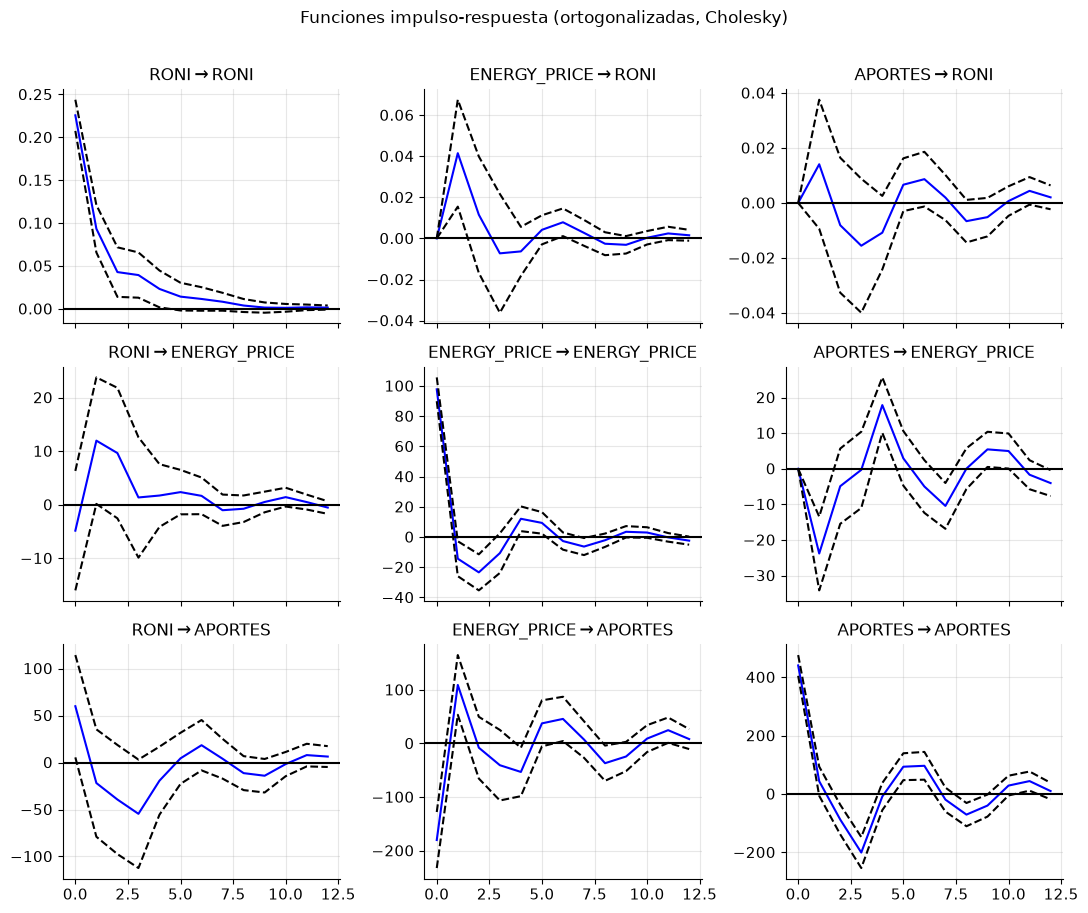

In [63]:
HORIZONTE_IRF = 12
irf = resultado_var.irf(HORIZONTE_IRF)

fig = irf.plot(orth=True, figsize=(11, 9))
fig.suptitle("Funciones impulso-respuesta (ortogonalizadas, Cholesky)", y=1.01)
plt.tight_layout()
plt.show()


### 9.2 Interpretación dirigida a las preguntas del proyecto


In [64]:
def resumen_irf(irf_obj, variable_shock, variable_respuesta, columnas, horizonte):
    idx_shock = columnas.index(variable_shock)
    idx_resp = columnas.index(variable_respuesta)
    trayectoria = irf_obj.orth_irfs[:, idx_resp, idx_shock]
    efecto_max = trayectoria[np.argmax(np.abs(trayectoria))]
    periodo_max = int(np.argmax(np.abs(trayectoria)))
    return trayectoria, efecto_max, periodo_max

columnas = list(datos_var.columns)

print("Respuesta del PRECIO ante un shock en el ÍNDICE NIÑO 3.4:")
tray, efecto_max, periodo_max = resumen_irf(irf, "RONI", "ENERGY_PRICE", columnas, HORIZONTE_IRF)
print(f"  Efecto máximo: {efecto_max:.4f} en el mes {periodo_max}")
print(f"  Signo del efecto máximo: {'positivo' if efecto_max > 0 else 'negativo'}")

print("\nRespuesta de los APORTES HÍDRICOS ante un shock en el ÍNDICE NIÑO 3.4:")
tray2, efecto_max2, periodo_max2 = resumen_irf(irf, "RONI", "APORTES", columnas, HORIZONTE_IRF)
print(f"  Efecto máximo: {efecto_max2:.4f} en el mes {periodo_max2}")
print(f"  Signo del efecto máximo: {'positivo' if efecto_max2 > 0 else 'negativo'}")


Respuesta del PRECIO ante un shock en el ÍNDICE NIÑO 3.4:
  Efecto máximo: 11.9644 en el mes 1
  Signo del efecto máximo: positivo

Respuesta de los APORTES HÍDRICOS ante un shock en el ÍNDICE NIÑO 3.4:
  Efecto máximo: 59.9037 en el mes 0
  Signo del efecto máximo: positivo


Con base en los gráficos y los resúmenes numéricos anteriores, discuta explícitamente:

- **¿Cómo responde el precio ante un shock positivo del Índice Niño?** Observe el signo del primer tramo de la curva `Precio_Bolsa` en el panel `Indice_Nino34 → Precio_Bolsa`: un signo positivo sostenido durante varios meses es consistente con la hipótesis de transmisión climática hacia el precio.
- **¿Cómo responden los aportes?** Observe el panel `Indice_Nino34 → Aportes_Hidricos`: se espera un signo negativo si un shock cálido de ENSO reduce la hidrología esperada.
- **¿Cuánto tarda en disiparse el efecto?** Identifique el número de meses hasta que la curva de respuesta vuelve a cruzar el cero (o se estabiliza dentro de la banda de confianza). Esto es información directamente relevante para el **horizonte de cobertura** de un derivado climático.
- **¿Cuál es la magnitud?** Compare el efecto máximo reportado arriba contra la desviación estándar histórica de `Precio_Bolsa` para juzgar si el efecto es económicamente relevante, no solo estadísticamente significativo.
- **¿Existen efectos persistentes?** Si la IRF no converge claramente a cero dentro del horizonte de 12 meses, esto podría señalar un efecto de mediano plazo o, alternativamente, ser síntoma de un problema de estabilidad revisado en la Sección 7.1.

**Conclusión de la sección:** las IRF constituyen la evidencia dinámica central del proyecto: cuantifican signo, magnitud y duración de la transmisión desde el Índice Niño 3.4 hacia los aportes hídricos y el precio de bolsa, información indispensable para calibrar el subyacente y el horizonte de un derivado climático.


## 10. Descomposición de la varianza del error de pronóstico (FEVD)

**Qué mide:** la FEVD descompone la varianza del error de pronóstico de cada variable, en cada horizonte $h$, en las proporciones atribuibles a shocks propios y a shocks de las demás variables del sistema.

**Para qué sirve:** mientras las IRF muestran la dirección y magnitud temporal de un shock, la FEVD cuantifica **cuánta importancia relativa** tiene cada fuente de shock en explicar la incertidumbre futura de una variable — un complemento natural para responder: *¿qué tan relevante es el riesgo climático frente a otras fuentes de variabilidad del precio?*

**Cómo complementa las IRF:** una IRF puede mostrar un efecto de signo claro pero de magnitud pequeña; la FEVD permite confirmar si ese canal es, en términos relativos, una fuente importante de varianza o marginal frente a la inercia propia de la serie.


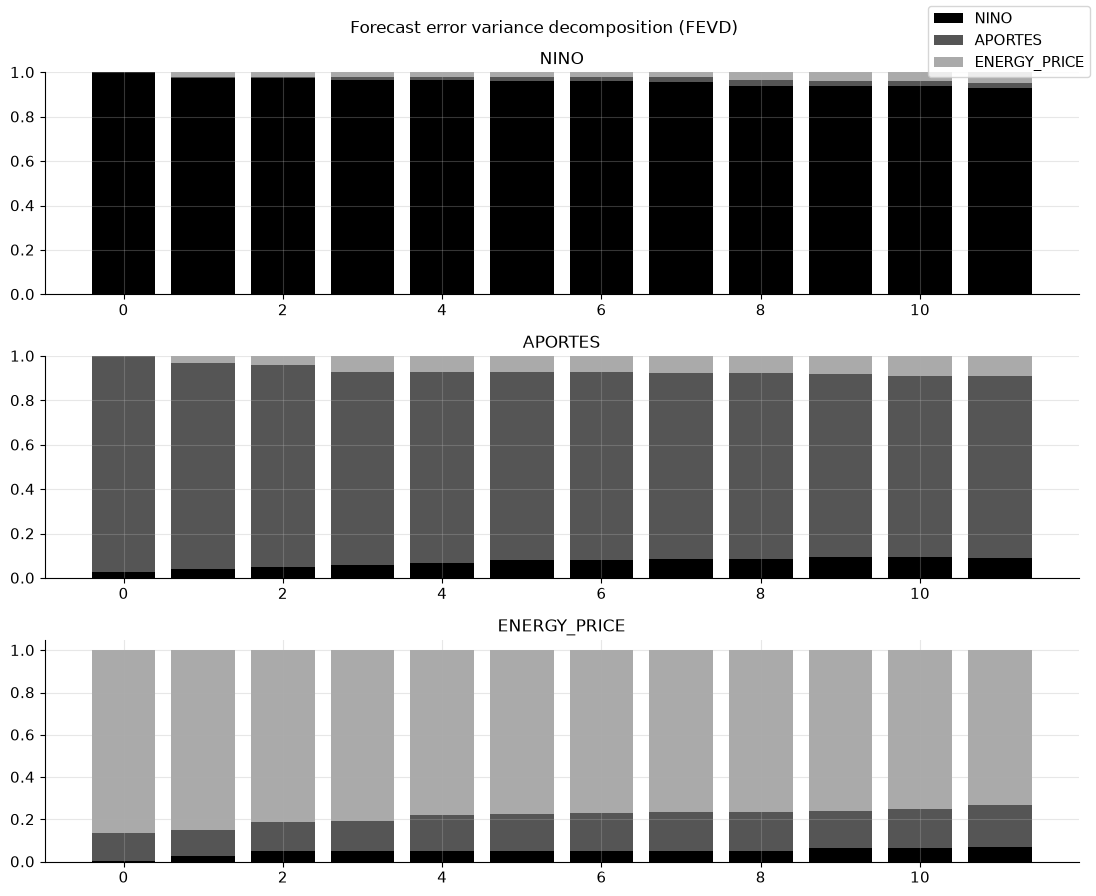

In [ ]:
fevd = resultado_var.fevd(HORIZONTE_IRF)

fig = fevd.plot(figsize=(11, 9))
plt.tight_layout()
plt.show()


In [ ]:
def tabla_fevd_variable(fevd_obj, variable, columnas, horizontes=(1, 3, 6, 12)):
    idx = columnas.index(variable)
    datos_fevd = fevd_obj.decomp[idx]  # shape: (horizonte, n_variables)
    filas = []
    for h in horizontes:
        fila = {"Horizonte (meses)": h}
        for j, col in enumerate(columnas):
            fila[col] = round(datos_fevd[h - 1, j] * 100, 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Horizonte (meses)")

print("FEVD — Precio_Bolsa (porcentaje de varianza explicado por cada variable):")
tabla_fevd_precio = tabla_fevd_variable(fevd, "ENERGY_PRICE", columnas)
tabla_fevd_precio


FEVD — Precio_Bolsa (porcentaje de varianza explicado por cada variable):


,NINO,APORTES,ENERGY_PRICE
Horizonte (meses),,,
1,0.32,13.30,86.38
3,4.91,13.92,81.18
6,5.10,17.58,77.32
12,7.08,19.65,73.27


In [ ]:
print("FEVD — Aportes_Hidricos:")
tabla_fevd_aportes = tabla_fevd_variable(fevd, "APORTES", columnas)
tabla_fevd_aportes


FEVD — Aportes_Hidricos:


,NINO,APORTES,ENERGY_PRICE
Horizonte (meses),,,
1,2.72,97.28,0.00
3,4.94,91.04,4.02
6,7.94,84.80,7.26
12,9.03,82.07,8.90


In [ ]:
print("FEVD — Indice_Nino34:")
tabla_fevd_indice = tabla_fevd_variable(fevd, "NINO", columnas)
tabla_fevd_indice


FEVD — Indice_Nino34:


,NINO,APORTES,ENERGY_PRICE
Horizonte (meses),,,
1,100.00,0.00,0.00
3,97.35,0.61,2.05
6,96.22,1.65,2.13
12,92.92,2.37,4.71


**Interpretación:**

- **Precio_Bolsa:** revise qué porcentaje de su varianza a 12 meses es explicado por sí mismo (inercia propia), frente a lo explicado por `Indice_Nino34` y por `Aportes_Hidricos`. Un porcentaje creciente atribuible al Índice Niño conforme aumenta el horizonte respaldaría que el riesgo climático es una fuente de incertidumbre de precio cada vez más relevante en el mediano plazo — argumento directo a favor de coberturas climáticas de mediano plazo.
- **Aportes_Hidricos:** cuantifica cuánta de la incertidumbre hidrológica futura es atribuible al Índice Niño, validando (o no) al ENSO como predictor relevante de la oferta hídrica.
- **Indice_Nino34:** se espera que su propia varianza sea explicada mayoritariamente por sí misma (es la variable más exógena en el sistema, consistente con el ordenamiento de Cholesky utilizado), sirviendo como chequeo de consistencia del modelo.

**Conclusión de la sección:** la FEVD cuantifica la importancia relativa del canal climático dentro de la incertidumbre total del precio de bolsa, complementando el análisis de signo y magnitud de las IRF con una medida de relevancia relativa por horizonte.


## 11. Pronósticos del VAR

**Cómo funciona el pronóstico en un VAR:** dado el modelo estimado y los últimos $p$ valores observados de cada variable, el VAR genera pronósticos recursivos hacia adelante: el pronóstico del período $t+1$ se calcula con los valores observados en $t, t-1, \dots$; el pronóstico de $t+2$ utiliza el pronóstico de $t+1$ (en lugar de un dato observado) junto con los rezagos previos, y así sucesivamente. Esto implica que la incertidumbre del pronóstico —reflejada en las bandas de confianza— crece con el horizonte.


In [ ]:
HORIZONTE_PRONOSTICO = 12
valores_iniciales = datos_var.values[-REZAGO_OPTIMO:]

pronostico, banda_inferior, banda_superior = resultado_var.forecast_interval(
    valores_iniciales, steps=HORIZONTE_PRONOSTICO, alpha=0.05
)

fechas_pronostico = pd.date_range(
    start=datos_var.index[-1] + pd.DateOffset(months=1),
    periods=HORIZONTE_PRONOSTICO, freq="MS"
)

df_pronostico = pd.DataFrame(pronostico, index=fechas_pronostico, columns=datos_var.columns)
df_banda_inf = pd.DataFrame(banda_inferior, index=fechas_pronostico, columns=datos_var.columns)
df_banda_sup = pd.DataFrame(banda_superior, index=fechas_pronostico, columns=datos_var.columns)

df_pronostico


,NINO,APORTES,ENERGY_PRICE
2025-01-01,-0.084481,-995.040597,-47.188163
2025-02-01,0.173251,-732.921581,153.840949
2025-03-01,0.130194,722.384102,-109.428774
2025-04-01,0.004083,1020.496274,-11.989140
2025-05-01,-0.011237,1769.931253,-149.530976
2025-06-01,-0.123799,452.064789,-190.647732
2025-07-01,-0.011212,-578.807030,-117.509580
2025-08-01,0.000445,-1651.392927,241.363223
2025-09-01,0.319453,-359.955362,214.748150
2025-10-01,0.079354,803.479496,209.358622


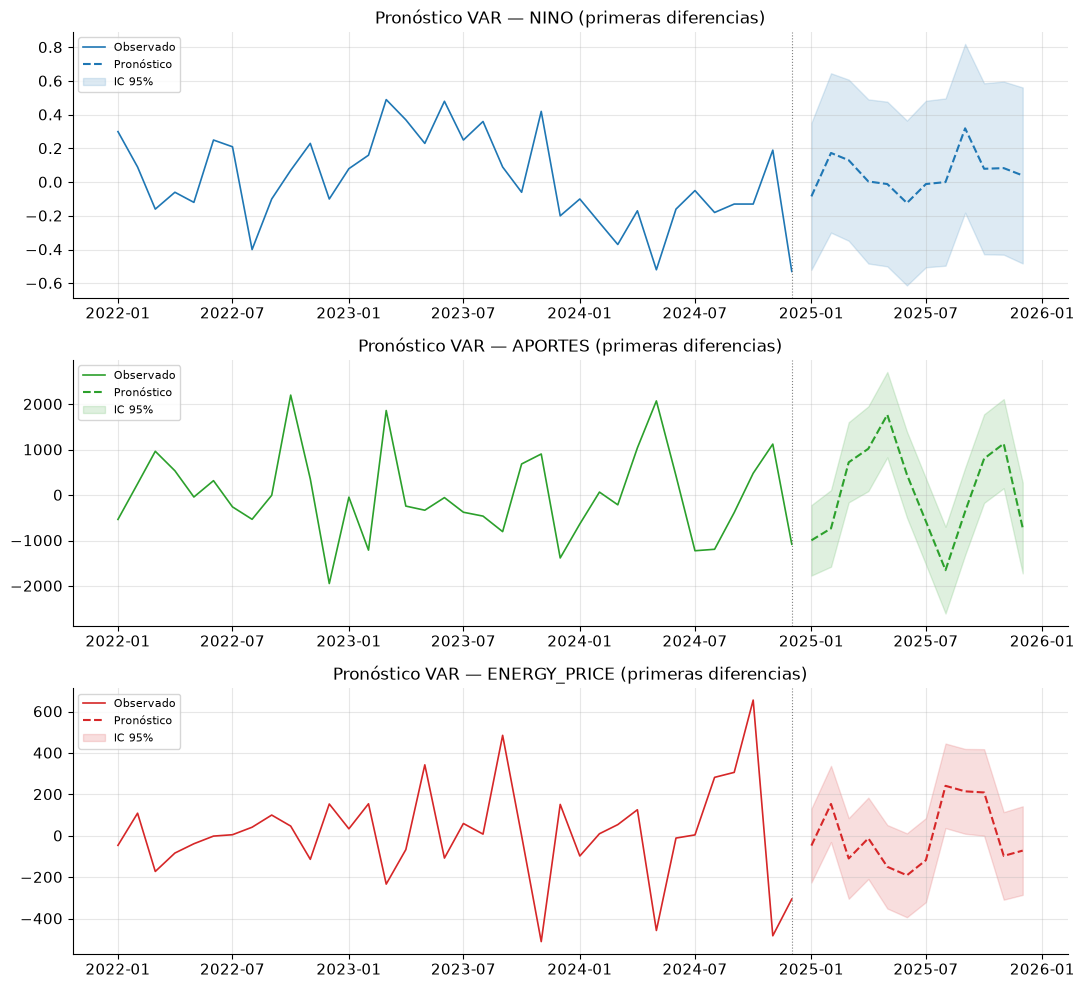

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=False)
n_hist = 36  # últimos 36 meses observados, para contexto visual

for ax, col, color in zip(axes, datos_var.columns, colores):
    historico = datos_var[col].iloc[-n_hist:]
    ax.plot(historico.index, historico.values, color=color, label="Observado", linewidth=1.2)
    ax.plot(df_pronostico.index, df_pronostico[col], color=color, linestyle="--",
             label="Pronóstico", linewidth=1.5)
    ax.fill_between(df_pronostico.index, df_banda_inf[col], df_banda_sup[col],
                      color=color, alpha=0.15, label="IC 95%")
    ax.axvline(datos_var.index[-1], color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(f"Pronóstico VAR — {col} ({transformacion})")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


**Interpretación:** observe el ancho creciente de la banda de confianza a medida que aumenta el horizonte —reflejo de la acumulación de incertidumbre propia del pronóstico recursivo—, así como la dirección del pronóstico puntual de `Precio_Bolsa`. Recuerde que, si el VAR se estimó sobre series diferenciadas (ver `transformacion` en la Sección 4), estos pronósticos corresponden a **cambios** period-a-período y no a niveles; para obtener pronósticos en niveles sería necesario acumular (`cumsum`) el pronóstico diferenciado sobre el último valor observado en niveles.

**Conclusión de la sección:** el ejercicio de pronóstico ilustra la capacidad predictiva práctica del VAR estimado y provee una primera aproximación cuantitativa útil para dimensionar escenarios de precio ante la trayectoria esperada del Índice Niño 3.4 y los aportes hídricos.


## 12. Conclusiones del análisis

Esta sección debe completarse **con los resultados numéricos obtenidos al ejecutar el notebook sobre los datos reales**, ya que las conclusiones dependen de los valores concretos de las pruebas. A modo de guía, responda explícitamente cada una de las siguientes preguntas usando los resultados de las secciones anteriores:

**¿Existe evidencia de interacción dinámica entre las tres variables?**
Revise conjuntamente los resultados de estacionariedad (Sección 4), estabilidad del VAR (Sección 7.1) y significancia de los coeficientes rezagados (Sección 6) para responder si el sistema, en su conjunto, exhibe una dinámica interdependiente coherente con la teoría.

**¿Qué relaciones parecen más fuertes?**
Compare la significancia estadística (Sección 6), los resultados de Granger (Sección 8) y la magnitud/persistencia de las IRF (Sección 9) para identificar cuál de las seis direcciones de transmisión evaluadas presenta la evidencia más consistente.

**¿Qué reveló la prueba de causalidad de Granger?**
Sintetice la tabla de la Sección 8: ¿el Índice Niño Granger-causa a los aportes y/o al precio? ¿Los aportes Granger-causan al precio? Discuta si el patrón de p-values respalda la cadena de transmisión clima → hidrología → precio.

**¿Qué mostraron las funciones impulso-respuesta?**
Resuma signo, magnitud y tiempo de disipación de los efectos relevantes identificados en la Sección 9, en particular la respuesta del precio ante un shock del Índice Niño.

**¿Qué mostró la descomposición de varianza (FEVD)?**
Indique qué porcentaje de la varianza del precio a 12 meses es atribuible al Índice Niño y a los aportes hídricos, según la Sección 10, y si esa proporción es económicamente relevante.

**¿El VAR parece apropiado para este problema?**
Evalúe conjuntamente los diagnósticos de la Sección 7 (estabilidad, autocorrelación, normalidad, heterocedasticidad). Un VAR estable con residuos aproximadamente ruido blanco respalda la validez de las conclusiones anteriores; problemas de especificación detectados deben matizar la confianza en los resultados.

**¿Cuáles son las limitaciones del análisis?**

- El VAR captura relaciones **lineales**; la relación entre ENSO y variables hidroclimáticas puede tener componentes no lineales (p. ej., efectos de umbral) no capturados aquí.
- La longitud de la muestra mensual limita la potencia de las pruebas de raíz unitaria y la precisión de la estimación con rezagos altos.
- No se implementó una prueba formal y directa de heterocedasticidad multivariada de residuos del VAR (limitación de `statsmodels` documentada en la Sección 7.4); se empleó una aproximación univariada.
- El ordenamiento de Cholesky utilizado en las IRF y la FEVD impone un supuesto de exogeneidad contemporánea (`Indice_Nino34` no es afectado contemporáneamente por las otras dos variables) que, si bien es razonable desde la física del clima, es una simplificación que debe declararse explícitamente.
- El análisis no incorpora variables de control adicionales relevantes para el mercado eléctrico colombiano (p. ej., demanda, disponibilidad térmica, transmisión internacional), lo que podría sesgar la magnitud de los efectos atribuidos exclusivamente al canal climático.

---

**Implicación para el diseño del derivado climático:** en la medida en que las secciones 8, 9 y 10 confirmen que el Índice Niño 3.4 tiene poder predictivo estadísticamente significativo y económicamente relevante sobre el precio de bolsa —con un horizonte de transmisión identificable en las IRF—, este análisis provee sustento cuantitativo para estructurar un derivado indexado al Índice Niño 3.4 (por ejemplo, un swap o una opción climática) como instrumento de cobertura del riesgo de precio en el mercado eléctrico colombiano, con el horizonte de disipación de las IRF como referencia para el tenor del contrato.
